In [1]:
import torch
import matplotlib.pyplot as plt
from typing import Tuple 
import os
import matplotlib.pyplot as plt
from skfmm import distance
from torch.utils.data import DataLoader
from torchvision.datasets import OxfordIIITPet
import preprocess_dataset
import losses
from main_network import DecompositionNetwork
from tqdm import tqdm
from visualize_rectangle import rectangle_on_img

In [2]:
# Hyperparameters:
LEARNING_RATE = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
NUM_EPOCHS = 7
LOAD_MODEL = False
NUM_WORKERS = os.cpu_count()

In [3]:
train_dataset = preprocess_dataset.OxfordIIITPet_Distancefields_train()
test_dataset = preprocess_dataset.OxfordIIITPet_Distancefields_test()

In [4]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

torch.Size([16, 3, 256, 256])


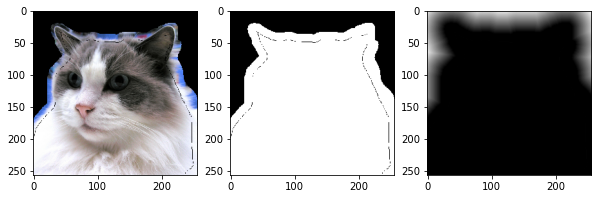

In [5]:
_, ax = plt.subplots(1,3, figsize=(10,10))

for x, y in train_dataloader:
    x_masked = preprocess_dataset.mask_rgb_imgs(x, y)
    print(x_masked.shape)
    ax[0].imshow(torch.permute(x_masked[0], (1, 2, 0)))
    ax[1].imshow(torch.squeeze(y[0][0]), cmap="gray")
    ax[2].imshow(torch.squeeze(y[0][1]), cmap="gray")
    break

In [6]:
# #_, ax = plt.subplots(1,3, figsize=(10,10))
# for data, targets in train_dataloader:
#     # take out the background by applying GT mask
#     masked_data = preprocess_dataset.mask_rgb_imgs(data, targets)
#     masked_data = masked_data.float()
#     targets = torch.permute(targets, (2, 1, 0, 3, 4))
#     targets = targets.float()

#     print(len(targets))
#     print(targets.shape)

#     predictions = torch.tensor([
#         [100, 100, 150, 150] for i in range(16)
#         ])
#     print(predictions.shape)
#     loss =losses.all_loss_fn(
#         predictions, 
#         mask_y=torch.squeeze(targets[0][0]),
#         field_y=torch.squeeze(targets[0][1]),
#         device="cpu"
#         )
#     break


In [19]:
def train(primitive_dict, loader, model, optimizer, loss_fn, consis_weight, mask_factor, scaler, device):
    model = model.to(device)
    cov = []
    cons = []
    negative = []

    # data is rgb without background taken out
    # target is in first dim the y_mask and second dim is distance field
    for data, targets in (pbar:= tqdm(loader)):
        # take out the background by applying GT mask
        masked_data = preprocess_dataset.mask_rgb_imgs(data, targets)
        masked_data = masked_data.float().to(device)
        targets = torch.permute(targets, (2, 1, 0, 3, 4))
        targets = targets.float().to(device)
        # train data but with only the binary mask
        x_targets = torch.permute(targets, (1, 2, 0, 3, 4 ))[0]

        # forward pass
        with torch.cuda.amp.autocast():
            predictions = model(x_targets)
            loss, vals = loss_fn(
                predictions, 
                primitive_dict,
                mask_y=torch.squeeze(targets[0, 0]),
                field_y=torch.squeeze(targets[0, 1]),
                device=device,
                consis_weight=consis_weight,
                mask_factor=mask_factor,
                )
        
        optimizer.zero_grad()
        # backward pass
        # backward = scaler.scale(loss).backward()
        # print(backward)
        # scaler.step(optimizer)
        # scaler.update()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        # print(loss) 
        optimizer.step()

        # update tqdm loop
        cov.append(vals[0].item())
        cons.append(vals[1].item())
        negative.append(vals[2].item())
        pbar.set_postfix(loss=(vals[0].item(),vals[1].item(), vals[2].item()))
    return cov, cons

In [20]:
# triangles and squares are not defined yet
prim_dict = {"Rectangles": 3, "Triangles": 0, "Squares": 0}
model = DecompositionNetwork(prim_dict, batch_size=BATCH_SIZE, bias=0.1)
optim = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler()


for epoch in range(NUM_EPOCHS):
    cov_losses, cons_losses = train(
        prim_dict,
        train_dataloader, 
        model, 
        optim, 
        losses.all_loss_fn, 
        10000,
        0.02,
        scaler, 
        device=DEVICE,
        )

model.to(device="cpu")
torch.cuda.empty_cache()            

100%|██████████| 230/230 [00:23<00:00,  9.71it/s, loss=(157.88955688476562, 79.96825408935547, -0.0)] 


torch.Size([16, 1, 256, 256])


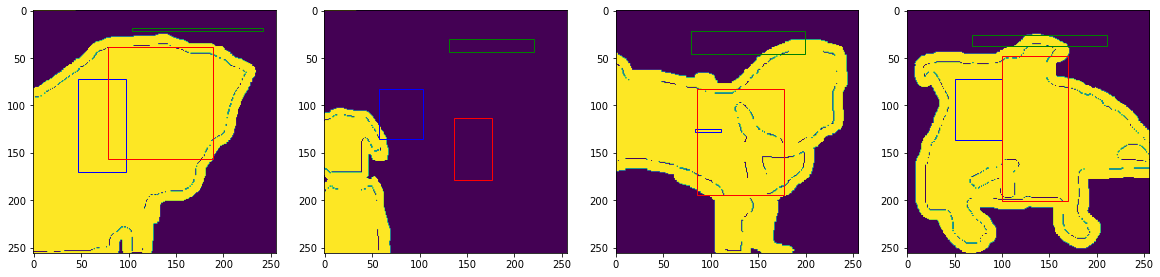

In [32]:
import importlib
import visualize_rectangle
importlib.reload(visualize_rectangle)

# _, ax = plt.subplots(1,3, figsize=(10,10))
for x, y in train_dataloader:
    y_masked = torch.permute(y, (1, 0, 2, 3, 4 ))[0]
    x_masked = preprocess_dataset.mask_rgb_imgs(x,y)
    predict= model(y_masked.float())
    torch.set_printoptions(precision=2, sci_mode=False)
    # plt.imshow(torch.permute(y[0, 0, 0], (1, 2, 0)))
    # plt.imshow(y[0, 0, 0], cmap="gray")
    visualize_rectangle.rectangle_on_img(prim_dict, y_masked, predict.detach(), mode="rgb")

    # for i in range(prim_dict["Rectangles"]):
    #     print(predict[i, 0])
    break

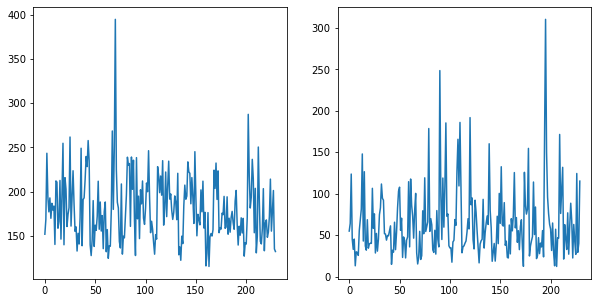

In [ ]:
_, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(cov_losses)
ax[1].plot(cons_losses)
plt.show()